## 0 · Setup

## Notebook for protocol 1 serves as a baseline for all single imagery models used in the thesis. This run addrresses the GT year single imagery training reffered to as Run 2 in the report. Working name for this run was Run 32.

In [ ]:
!pip install rasterio imagecodecs scikit-image scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 104.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/A_Thesis')

import os, glob, random, time
import numpy as np
import rasterio
import tensorflow as tf
import psutil
from skimage.util import random_noise

from utils_b import (
    fix_random_seeds, get_class_weights, softmax_with_temperature,
    CustomMacroF1Score, custom_categorical_crossentropy,
)
from resunet import res_unet

fix_random_seeds(42)
print('TF:', tf.__version__)


TF: 2.19.0


## 1 · Configuration


In [ ]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DRIVE_ROOT      = '/content/drive/MyDrive'
IMG_ROOT        = os.path.join(DRIVE_ROOT, 'Final_GEE_Exports')
GT_ROOT         = os.path.join(DRIVE_ROOT,
                  'GEE_Exports quarter_only/Driver_test/clipped_outputs')
DATA_DIR        = '/content/data'
EXP_DIR         = '/content/exp'
DRIVE_CACHE_DIR = os.path.join(DRIVE_ROOT, 'numpy_cache')

# ── RUN MODE ──────────────────────────────────────────────────────────────────
# Run 2: INPUT_YEAR = 2024    GT year imagery  (same year as labels)
# Run 3: INPUT_YEAR = 2025    post-disturbance (one year after labels)
GT_YEAR    = 2024
INPUT_YEAR = 2024   # change to 2025 for Run 3

# ── Month + composite settings ────────────────────────────────────────────────

COMPOSITE_MONTHS : [2, 5, 8, 11]
# default s2_quarterly : [2, 5, 8, 11]  (Feb, May, Aug, Nov)

# COMPOSITE_MONTHS = [1,2,3,4,5,6,7,8,9,10,11,12]
COMPOSITE_MODE = 'mean'

# ── AOI universe ──────────────────────────────────────────────────────────────
ALL_AOIS         = [f'AOI_{i}' for i in range(13) if i not in (1, 8, 9)]
REQUIRED_DRIVERS = {1, 2, 3}

# ── AOI split —
TRAIN_INCOMPLETE_AOIS = ['AOI_0', 'AOI_10', 'AOI_11', 'AOI_12']
TRAIN_AOIS_MANUAL     = ['AOI_7', 'AOI_6', 'AOI_3']
VAL_AOIS_MANUAL       = ['AOI_2']
TEST_AOIS_MANUAL      = ['AOI_4', 'AOI_5']  # held-out — never seen during training

# ── Bands / classes ───────────────────────────────────────────────────────────
ALL_BAND_NAMES = ['B3', 'B4', 'B8', 'B12', 'VV', 'VH']
NB_CLASSES     = 3      # 0=bark-beetle  1=mgmt  2=wind-throw  (255=ignored)
N_BANDS        = len(ALL_BAND_NAMES)   # 6

# ── Hyperparameters
SIZE_CROPS            = 128
BATCH_SIZE            = 4
N_SAMPLES_TRAIN       = 3200
N_SAMPLES_VAL         = 1600
EPOCHS                = 14
BASE_LR               = 1e-4
FINAL_LR              = 1e-6
TEMPERATURE           = 10
AUGMENT               = True
AUGMENT_ROTATE        = True
DIST_CENTER_PROB      = 0.80
WIND_THROW_OVERSAMPLE = 0.15
WEIGHT_DECAY          = 2e-4
LR_SCHEDULE           = 'cosine'

if COMPOSITE_MODE == 'mean':
    N_TIMESTEPS    = 1
    TOTAL_CHANNELS = N_BANDS          # 6
else:  # 'stack'
    N_TIMESTEPS    = len(COMPOSITE_MONTHS)
    TOTAL_CHANNELS = N_BANDS * N_TIMESTEPS

STEPS_PER_EPOCH  = N_SAMPLES_TRAIN // BATCH_SIZE
VALIDATION_STEPS = N_SAMPLES_VAL   // BATCH_SIZE   #

# Month labels — e.g. ['2024_M02', '2024_M05', '2024_M08', '2024_M11']
MONTH_LABELS = [f'{INPUT_YEAR}_M{m:02d}' for m in COMPOSITE_MONTHS]

# Cache tag — encodes year + months + mode: different configs never share cache
_mo_str  = ''.join(f'{m:02d}' for m in COMPOSITE_MONTHS)
CACHE_TAG = f'p1_{INPUT_YEAR}_M{_mo_str}_{COMPOSITE_MODE}'

# Run label for filenames and plot titles
RUN_LABEL = (f'Run2_P1_{INPUT_YEAR}_{COMPOSITE_MODE}_{len(COMPOSITE_MONTHS)}mo'
             if INPUT_YEAR == GT_YEAR
             else f'Run3_P1_{INPUT_YEAR}_{COMPOSITE_MODE}_{len(COMPOSITE_MONTHS)}mo')

for d in [DATA_DIR, EXP_DIR, DRIVE_CACHE_DIR,
          os.path.join(DATA_DIR, 'train'),
          os.path.join(DATA_DIR, 'val'),
          os.path.join(DATA_DIR, 'test')]:
    os.makedirs(d, exist_ok=True)

print(f'Config OK — {RUN_LABEL}')
print(f'  INPUT_YEAR : {INPUT_YEAR}  (GT year: {GT_YEAR})')
print(f'  Months     : {MONTH_LABELS}')
print(f'  Mode       : {COMPOSITE_MODE}  → {N_TIMESTEPS} timestep(s), {TOTAL_CHANNELS} channels')
print(f'  Train AOIs : {TRAIN_AOIS_MANUAL} + incomplete {TRAIN_INCOMPLETE_AOIS}')
print(f'  Val        : {VAL_AOIS_MANUAL}')
print(f'  Test       : {TEST_AOIS_MANUAL}  (held-out)')
print(f'  Cache tag  : {CACHE_TAG}')
print(f'  Steps/epoch: {STEPS_PER_EPOCH}  |  val steps: {VALIDATION_STEPS}')


Config OK — Run2_P1_2024_mean_4mo
  INPUT_YEAR : 2024  (GT year: 2024)
  Months     : ['2024_M02', '2024_M05', '2024_M08', '2024_M11']
  Mode       : mean  → 1 timestep(s), 6 channels
  Train AOIs : ['AOI_7', 'AOI_6', 'AOI_3'] + incomplete ['AOI_0', 'AOI_10', 'AOI_11', 'AOI_12']
  Val        : ['AOI_2']
  Test       : ['AOI_4', 'AOI_5']  (held-out)
  Cache tag  : p1_2024_M02050811_mean
  Steps/epoch: 800  |  val steps: 400


## 2 · Helper functions
Data-prep helpers, driver audit, and the dataloader class are defined here.
The **spatial mismatch fix** is in `align_gt_to_image()` (save-time)
and the defensive guard inside `MemmapNPYCropDataset.generator()` (load-time).

In [ ]:
def _normalise_band(arr_2d):
    """Per-band robust normalisation [0,1] via 2nd-98th percentile stretch."""
    p2, p98 = np.percentile(arr_2d, 2), np.percentile(arr_2d, 98)
    if p98 <= p2:
        return np.zeros_like(arr_2d, dtype=np.float32)
    return np.clip((arr_2d.astype(np.float32) - p2) / (p98 - p2), 0.0, 1.0)


def load_monthly_tifs(aoi, img_root, month_labels, drive_root = DRIVE_ROOT):
    """
    Load TIF composites for the given month labels and return a raw uint16 stack.
    File pattern: <img_root>/<aoi>/<aoi>_<YYYY_MNN>.tif
    Returns: (T, H, W, B) uint16, list of loaded labels
    """
    aoi_folder = os.path.join(DRIVE_ROOT, f'Final_GEE_Exports {aoi}')
    frames, loaded = [], []
    for label in month_labels:
        fpath = os.path.join(aoi_folder, f'{aoi}_{label}.tif')
        if not os.path.exists(fpath):
            print(f'    ⚠  Missing: {os.path.basename(fpath)} — skipping')
            continue
        with rasterio.open(fpath) as src:
            arr = src.read().transpose(1, 2, 0).astype(np.uint16)  # (H,W,B)
        frames.append(arr)
        loaded.append(label)
    if not frames:
        raise FileNotFoundError(
            f'No composites found for {aoi} in {aoi_folder}\n'
            f'Expected month labels: {month_labels}')
    stack = np.stack(frames, axis=0)   # (T, H, W, B) uint16
    print(f'  [{aoi}] loaded {len(frames)} month(s) → {stack.shape}')
    return stack, loaded


def build_composite(stack_raw, mode):
    """
    Convert a raw (T, H, W, B) uint16 stack to a normalised float32 array.

    mode='stack' → (T, H, W, B) float32  each month is its own timestep
    mode='mean'  → (1, H, W, B) float32  all months averaged into one frame
    """
    T, H, W, B = stack_raw.shape
    if mode == 'mean':
        mean_arr = stack_raw.astype(np.float32).mean(axis=0)  # (H, W, B)
        result   = np.empty((1, H, W, B), dtype=np.float32)
        for b in range(B):
            result[0, :, :, b] = _normalise_band(mean_arr[:, :, b])
        return result
    else:  # 'stack'
        result = np.empty((T, H, W, B), dtype=np.float32)
        for t in range(T):
            for b in range(B):
                result[t, :, :, b] = _normalise_band(
                    stack_raw[t, :, :, b].astype(np.float32))
        return result


def load_gt(aoi, gt_root):
    """
    Load GT TIF and remap to 0-indexed 3-class labels
      raw 1 (bark-beetle) → 0
      raw 2 (mgmt)   → 1
      raw 3 (wind-throw)  → 2
      raw 0 (background)  → 255  (ignored by loss)
      raw 255 (nodata)    → 255
    """
    gt_path = os.path.join(gt_root, f'{aoi}_drivers.tif')
    with rasterio.open(gt_path) as src:
        raw = src.read(1).astype(np.int16)
    gt           = np.full_like(raw, 255, dtype=np.uint8)
    gt[raw == 1] = 0
    gt[raw == 2] = 1
    gt[raw == 3] = 2
    counts  = {c: int((gt == c).sum()) for c in [0, 1, 2]}
    n_valid = sum(counts.values())
    print(f'  [{aoi}] GT {gt.shape}  driver px: {n_valid:,}  '
          f'bb={counts[0]:,}  mgmt={counts[1]:,}  wt={counts[2]:,}')
    return gt


def align_gt_to_image(stack, gt, aoi):
    """Crop/pad GT to match image spatial dims (GEE CRS rounding fix)."""
    H_img, W_img = stack.shape[1], stack.shape[2]
    H_gt,  W_gt  = gt.shape
    if (H_gt, W_gt) == (H_img, W_img):
        return gt
    h = min(H_img, H_gt);  w = min(W_img, W_gt)
    gt = gt[:h, :w]
    if h < H_img or w < W_img:
        gt = np.pad(gt, ((0, H_img - h), (0, W_img - w)), constant_values=255)
    print(f'    [{aoi}] spatial fix: GT({H_gt},{W_gt}) → img({H_img},{W_img})')
    return gt


def audit_aoi_drivers(gt_root, all_aois, required=None):
    """Return (complete_aois, incomplete_list) — checks Drive GT TIFs directly."""
    if required is None:
        required = {1, 2, 3}
    complete, incomplete = [], []
    for aoi in all_aois:
        candidates = [
            os.path.join(gt_root, f'{aoi}_drivers.tif'),
            os.path.join(DATA_DIR, 'train', f'{aoi}_gt.npy'),
            os.path.join(DATA_DIR, 'val',   f'{aoi}_gt.npy'),
            os.path.join(DATA_DIR, 'test',  f'{aoi}_gt.npy'),
        ]
        gt_path = next((p for p in candidates if os.path.exists(p)), None)
        if gt_path is None:
            print(f'  ⚠  {aoi}: no GT file found')
            incomplete.append((aoi, required))
            continue
        if gt_path.endswith('.tif'):
            with rasterio.open(gt_path) as src:
                arr = src.read(1).astype(np.int16)
            present = set(int(v) for v in np.unique(arr) if v not in (0, 255))
        else:
            arr     = np.load(gt_path).astype(np.int16)
            present = {v + 1 for v in np.unique(arr) if v in (0, 1, 2)}
        missing = required - present
        if missing:
            incomplete.append((aoi, missing))
        else:
            complete.append(aoi)
    return complete, incomplete

print('Helper functions defined.')


Helper functions defined.


In [ ]:
IMG_CACHE  = {}   # {img_path → (T, H, W, B) float32}
GT_CACHE   = {}   # {gt_path  → (H, W) uint8}
DIST_CACHE = {}   # {gt_path  → (valid_ys, valid_xs)}


def build_ram_cache(img_paths, gt_paths, tile_size):
    """Load every AOI .npy into RAM once. Precomputes disturbance centres."""
    global IMG_CACHE, GT_CACHE, DIST_CACHE
    IMG_CACHE.clear(); GT_CACHE.clear(); DIST_CACHE.clear()
    half = tile_size // 2
    total_mb = 0;  t0 = time.time()
    for img_path, gt_path in zip(img_paths, gt_paths):
        aoi   = os.path.basename(img_path).replace('_input.npy', '')
        t1    = time.time()
        stack = np.load(img_path)   # (T, H, W, B)
        gt    = np.load(gt_path)    # (H, W)
        IMG_CACHE[img_path] = stack
        GT_CACHE[gt_path]   = gt
        H, W   = gt.shape
        ys, xs = np.where(np.isin(gt, [0, 1, 2]))
        valid  = ((ys >= half) & (ys < H - half) &
                  (xs >= half) & (xs < W - half))
        DIST_CACHE[gt_path] = (ys[valid].copy(), xs[valid].copy())
        mb        = (stack.nbytes + gt.nbytes) / 1e6
        total_mb += mb
        print(f'  {aoi}: {stack.shape}  {mb:.0f} MB  '
              f'dist centres: {valid.sum():,}  ({time.time()-t1:.1f}s)')
    avail = psutil.virtual_memory().available / 1e6
    print(f'\n✓ Cached {len(IMG_CACHE)} AOIs in {time.time()-t0:.1f}s  '
          f'| {total_mb:.0f} MB used  | {avail:.0f} MB remaining')


class FastCropDataset(tf.data.Dataset):
    """
    RAM-backed disturbance-centred crop dataset.

    """

    def __new__(cls, image_paths, gt_paths,
                tile_size, batch_size, total_channels,
                n_bands_per_ts, samples, augment):

        def generator():
            n = len(image_paths)
            for _ in range(samples):
                i        = np.random.randint(0, n)
                img_path = image_paths[i]
                gt_path  = gt_paths[i]

                stack = IMG_CACHE[img_path]   # (T, H, W, B)
                gt    = GT_CACHE[gt_path]     # (H, W)
                T, H, W, B = stack.shape

                # Spatial guard
                if (H, W) != gt.shape:
                    h = min(H, gt.shape[0]);  w = min(W, gt.shape[1])
                    stack = stack[:, :h, :w, :];  gt = gt[:h, :w]
                    H, W  = h, w

                # Pad if AOI smaller than tile
                if H < tile_size or W < tile_size:
                    ph = max(0, tile_size - H);  pw = max(0, tile_size - W)
                    stack = np.pad(stack, ((0,0),(0,ph),(0,pw),(0,0)))
                    gt    = np.pad(gt,    ((0,ph),(0,pw)), constant_values=255)
                    H, W  = stack.shape[1], stack.shape[2]

                half     = tile_size // 2
                dys, dxs = DIST_CACHE[gt_path]
                ok       = ((dys >= half) & (dys < H - half) &
                            (dxs >= half) & (dxs < W - half))
                dys, dxs = dys[ok], dxs[ok]

                o = min(60, tile_size // 2 - 1)

                # Wind-throw oversampling
                _wt_ys, _wt_xs = np.array([]), np.array([])
                if len(dys) > 0:
                    _wt_mask = (gt[dys, dxs] == 2)
                    if _wt_mask.any():
                        _wt_ys = dys[_wt_mask];  _wt_xs = dxs[_wt_mask]
                _force_wt = (len(_wt_ys) > 0 and
                             random.random() < WIND_THROW_OVERSAMPLE)

                if _force_wt:
                    k = np.random.randint(0, len(_wt_ys))
                    r = int(np.clip(_wt_ys[k] - half + random.randint(-o, o),
                                    0, H - tile_size))
                    c = int(np.clip(_wt_xs[k] - half + random.randint(-o, o),
                                    0, W - tile_size))
                elif len(dys) > 0 and random.random() < DIST_CENTER_PROB:
                    k = np.random.randint(0, len(dys))
                    r = int(np.clip(dys[k] - half + random.randint(-o, o),
                                    0, H - tile_size))
                    c = int(np.clip(dxs[k] - half + random.randint(-o, o),
                                    0, W - tile_size))
                else:
                    r = np.random.randint(0, max(1, H - tile_size + 1))
                    c = np.random.randint(0, max(1, W - tile_size + 1))

                crop_stk = stack[:, r:r+tile_size, c:c+tile_size, :]  # (T,t,t,B)
                crop_ref = gt[r:r+tile_size, c:c+tile_size].copy().astype(np.float32)

                if np.all(crop_ref == 255):
                    continue

                # (T, tile, tile, B) → (tile, tile, T*B)
                T_, H_, W_, B_ = crop_stk.shape
                crop_img = crop_stk.transpose(1, 2, 0, 3).reshape(H_, W_, T_ * B_)
                crop_img = crop_img.astype(np.float32)

                # Augmentation —
                if augment:
                    if random.random() < 0.5:
                        crop_img = np.fliplr(crop_img);  crop_ref = np.fliplr(crop_ref)
                    if random.random() < 0.5:
                        crop_img = np.flipud(crop_img);  crop_ref = np.flipud(crop_ref)
                    if AUGMENT_ROTATE and random.random() < 0.75:
                        k = random.randint(1, 3)
                        crop_img = np.rot90(crop_img, k, axes=(0, 1)).copy()
                        crop_ref = np.rot90(crop_ref, k, axes=(0, 1)).copy()
                    if random.random() < 0.4:
                        from scipy.ndimage import map_coordinates, gaussian_filter
                        _sh = crop_img.shape[:2]
                        _dx = gaussian_filter(
                            np.random.randn(*_sh).astype(np.float32), sigma=4) * 6
                        _dy = gaussian_filter(
                            np.random.randn(*_sh).astype(np.float32), sigma=4) * 6
                        _x, _y = np.meshgrid(np.arange(_sh[1]), np.arange(_sh[0]))
                        _xi = np.clip(_x + _dx, 0, _sh[1]-1).astype(np.float32)
                        _yi = np.clip(_y + _dy, 0, _sh[0]-1).astype(np.float32)
                        _coords = [_yi.ravel(), _xi.ravel()]
                        for _ch in range(crop_img.shape[2]):
                            crop_img[..., _ch] = map_coordinates(
                                crop_img[..., _ch], _coords, order=1).reshape(_sh)
                        crop_ref = map_coordinates(
                            crop_ref, _coords, order=0).reshape(_sh)
                    if random.random() < 0.3:
                        n_opt = min(4, B_)
                        for t_i in range(T_):
                            s = t_i * B_
                            crop_img[..., s:s+n_opt] = random_noise(
                                crop_img[..., s:s+n_opt],
                                mode='gaussian', clip=True).astype(np.float32)

                yield crop_img, crop_ref

        output_sig = (
            tf.TensorSpec(shape=(tile_size, tile_size, total_channels), dtype=tf.float32),
            tf.TensorSpec(shape=(tile_size, tile_size),                  dtype=tf.float32),
        )
        ds = tf.data.Dataset.from_generator(generator, output_signature=output_sig)
        return ds.batch(batch_size).repeat().prefetch(tf.data.AUTOTUNE)

print('RAM cache + FastCropDataset defined.')


RAM cache + FastCropDataset defined.


## 3 · AOI Driver Audit

In [1]:
complete_aois, incomplete_aois = audit_aoi_drivers(GT_ROOT, ALL_AOIS, REQUIRED_DRIVERS)

print('\n' + '='*55)
print('AOI DRIVER AUDIT')
print('='*55)
print(f'  ✓ Complete   ({len(complete_aois)}): {complete_aois}')
print(f'  ✗ Incomplete ({len(incomplete_aois)}):')
for aoi, miss in incomplete_aois:
    print(f'      {aoi}  — missing: {miss}')

train_aois = TRAIN_AOIS_MANUAL + TRAIN_INCOMPLETE_AOIS
val_aois   = VAL_AOIS_MANUAL
test_aois  = TEST_AOIS_MANUAL

print(f'\n  → TRAIN ({len(train_aois)}): {train_aois}')
print(f'  → VAL   ({len(val_aois)}):   {val_aois}')
print(f'  → TEST  ({len(test_aois)}):  {test_aois}')

for a, b, lbl in [(train_aois, val_aois,  'train/val'),
                  (train_aois, test_aois, 'train/test'),
                  (val_aois,   test_aois, 'val/test')]:
    ov = set(a) & set(b)
    print(f'  {" OVERLAP" if ov else "✓ no overlap"}: {lbl}'
          + (f' → {ov}' if ov else ''))


NameError: name 'audit_aoi_drivers' is not defined

## 4 · Data Preparation
> **`align_gt_to_image()` is called here** — this is the primary fix.
> It ensures the `.npy` files saved to disk have exactly matching spatial dims.
> **Re-run this cell** if you previously saved `.npy` files and are hitting the shape error.

In [ ]:
import shutil

print('=' * 60)
print(f'DATA PREPARATION — Protocol 1  ({RUN_LABEL})')
print(f'  INPUT_YEAR   : {INPUT_YEAR}')
print(f'  Months       : {MONTH_LABELS}')
print(f'  Mode         : {COMPOSITE_MODE}  → {N_TIMESTEPS} timestep(s), {TOTAL_CHANNELS} ch')
print(f'  GT year      : {GT_YEAR}')
print(f'  Cache tag    : {CACHE_TAG}')
print('=' * 60)

os.makedirs(DRIVE_CACHE_DIR, exist_ok=True)

def _drive_img_path(aoi):
    return os.path.join(DRIVE_CACHE_DIR, f'{aoi}__{CACHE_TAG}__input.npy')

def _drive_gt_path(aoi):
    # GT does not depend on INPUT_YEAR, only GT_YEAR
    return os.path.join(DRIVE_CACHE_DIR, f'{aoi}__gt{GT_YEAR}.npy')

all_labels = []

for aoi_list, split in [(train_aois, 'train'),
                        (val_aois,   'val'),
                        (test_aois,  'test')]:
    if not aoi_list:
        print(f'  (no AOIs in {split} — skipping)')
        continue
    for aoi in aoi_list:
        if aoi in ('AOI_1', 'AOI_8', 'AOI_9'):
            print(f'  [{aoi}] skipped — no TIF data')
            continue
        print(f'\n── {aoi}  [{split}]  input={INPUT_YEAR}  GT={GT_YEAR}')
        out_dir   = os.path.join(DATA_DIR, split)
        local_img = os.path.join(out_dir, f'{aoi}_input.npy')
        local_gt  = os.path.join(out_dir, f'{aoi}_gt.npy')

        # ── INPUT COMPOSITE ───────────────────────────────────────────────────
        drive_img = _drive_img_path(aoi)
        if os.path.exists(drive_img):
            print(f'  [CACHE HIT]  input → {os.path.basename(drive_img)}')
            t0    = time.time()
            stack = np.load(drive_img)
            np.save(local_img, stack)
            print(f'  Loaded {stack.shape}  ({time.time()-t0:.1f}s)')
        else:
            print(f'  [CACHE MISS] building composite from TIFs …')
            t0         = time.time()
            raw, _     = load_monthly_tifs(aoi, IMG_ROOT, MONTH_LABELS)
            stack      = build_composite(raw, COMPOSITE_MODE)  # (T,H,W,B) float32
            del raw
            np.save(local_img, stack)
            np.save(drive_img, stack)
            print(f'  Saved {stack.shape} → local + Drive  ({time.time()-t0:.1f}s)')

        # ── GROUND TRUTH ──────────────────────────────────────────────────────
        drive_gt = _drive_gt_path(aoi)
        if os.path.exists(drive_gt):
            print(f'  [CACHE HIT]  GT')
            shutil.copy2(drive_gt, local_gt)
            gt = np.load(local_gt)
        else:
            print(f'  [CACHE MISS] GT — loading TIF')
            gt = load_gt(aoi, GT_ROOT)   # already 0-indexed (0/1/2/255)
            gt = align_gt_to_image(stack, gt, aoi)
            np.save(local_gt, gt)
            np.save(drive_gt, gt)
            print(f'  Saved GT {gt.shape}')

        # run alignment guard even on cache hit
        gt = align_gt_to_image(stack, gt, aoi)

        if split == 'train':
            valid = gt[gt != 255]
            assert set(np.unique(valid).tolist()).issubset({0, 1, 2}), \
                f'{aoi}: unexpected GT labels {np.unique(valid)}'
            all_labels.extend(valid.tolist())

np.save(os.path.join(DATA_DIR, 'labels.npy'), np.array(all_labels, dtype=np.int32))
print(f'\n✓ Data preparation complete')
print(f'  labels : {len(all_labels):,} px  unique: {np.unique(all_labels)}')
n_cached = len([f for f in os.listdir(DRIVE_CACHE_DIR) if f.endswith('.npy')])
print(f'  Drive cache: {n_cached} files  ({DRIVE_CACHE_DIR})')


DATA PREPARATION — Protocol 1  (Run2_P1_2024_mean_4mo)
  INPUT_YEAR   : 2024
  Months       : ['2024_M02', '2024_M05', '2024_M08', '2024_M11']
  Mode         : mean  → 1 timestep(s), 6 ch
  GT year      : 2024
  Cache tag    : p1_2024_M02050811_mean

── AOI_7  [train]  input=2024  GT=2024
  [CACHE MISS] building composite from TIFs …
  [AOI_7] loaded 4 month(s) → (4, 3308, 5001, 6)
  Saved (1, 3308, 5001, 6) → local + Drive  (31.7s)
  [CACHE MISS] GT — loading TIF
  [AOI_7] GT (3504, 3514)  driver px: 111,679  bb=103,877  mgmt=5,804  wt=1,998
  ⚠  [AOI_7] spatial fix: GT(3504,3514) → img(3308,5001)
  Saved GT (3308, 5001)

── AOI_6  [train]  input=2024  GT=2024
  [CACHE MISS] building composite from TIFs …
  [AOI_6] loaded 4 month(s) → (4, 3293, 5001, 6)
  Saved (1, 3293, 5001, 6) → local + Drive  (37.6s)
  [CACHE MISS] GT — loading TIF
  [AOI_6] GT (3590, 3599)  driver px: 7,306  bb=155  mgmt=7,115  wt=36
  ⚠  [AOI_6] spatial fix: GT(3590,3599) → img(3293,5001)
  Saved GT (3293, 5001)

## 5 · Build Datasets

In [ ]:
_labels_path = os.path.join(DATA_DIR, 'labels.npy')
if not os.path.exists(_labels_path):
    raise RuntimeError('labels.npy not found — re-run data preparation cell.')
labels_train = np.load(_labels_path)
print(f'Train label counts: { {c: int((labels_train==c).sum()) for c in [0,1,2]} }')
print(f'  (0=bark-beetle, 1=mgmt, 2=wind-throw)')

imgs_train = sorted(glob.glob(os.path.join(DATA_DIR, 'train', '*input.npy')))
gt_train   = sorted(glob.glob(os.path.join(DATA_DIR, 'train', '*gt.npy')))
imgs_val   = sorted(glob.glob(os.path.join(DATA_DIR, 'val',   '*input.npy')))
gt_val     = sorted(glob.glob(os.path.join(DATA_DIR, 'val',   '*gt.npy')))
imgs_test  = sorted(glob.glob(os.path.join(DATA_DIR, 'test',  '*input.npy')))
gt_test    = sorted(glob.glob(os.path.join(DATA_DIR, 'test',  '*gt.npy')))
print(f'Train ({len(imgs_train)}): {[os.path.basename(p) for p in imgs_train]}')
print(f'Val   ({len(imgs_val)}):   {[os.path.basename(p) for p in imgs_val]}')
print(f'Test  ({len(imgs_test)}):  {[os.path.basename(p) for p in imgs_test]}')

# ── Class weights ─────────────────────────────────────────────────────────────
weights_train = get_class_weights(labels_train)
for c in [0, 1, 2]:
    if c not in weights_train:
        weights_train[c] = 1.0
weights_train = dict(sorted(weights_train.items()))
values        = np.array(list(weights_train.values()))
weights_train = dict(zip(weights_train.keys(),
                         softmax_with_temperature(values, TEMPERATURE)))
print('Scaled weights (0=bb, 1=mgmt, 2=wt):', weights_train)

# ── RAM cache — train + val loaded now; test loaded lazily in §11 ─────────────
print('\nBuilding RAM cache (train + val)...')
build_ram_cache(imgs_train + imgs_val, gt_train + gt_val, SIZE_CROPS)

# ── Dataset kwargs — shared between train and val ─────────────────────────────
_kw = dict(tile_size=SIZE_CROPS, batch_size=BATCH_SIZE,
           total_channels=TOTAL_CHANNELS, n_bands_per_ts=N_BANDS)

train_dataset = FastCropDataset(
    imgs_train, gt_train, **_kw,
    samples=N_SAMPLES_TRAIN, augment=AUGMENT)

# ── Fixed validation set — seed=780,  ────────
if imgs_val:
    print('\nBuilding fixed validation set (seed=780, AOI_5)...')
    np.random.seed(780); random.seed(780)
    _val_gen = FastCropDataset(imgs_val, gt_val, **_kw,
                               samples=N_SAMPLES_VAL, augment=False)
    _val_x, _val_y = [], []
    for _xb, _yb in _val_gen.unbatch().take(N_SAMPLES_VAL):
        _val_x.append(_xb.numpy())
        _val_y.append(_yb.numpy())
    del _val_gen
    np.random.seed(None); random.seed(None)
    _val_x = np.stack(_val_x).astype(np.float32)
    _val_y = np.stack(_val_y).astype(np.float32)
    val_dataset = tf.data.Dataset.from_tensor_slices((_val_x, _val_y)) \
                    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    print(f'  Fixed val set: {_val_x.shape}  ({_val_x.nbytes/1e6:.0f} MB)')
    del _val_x, _val_y
else:
    val_dataset = None

# ── Shape check ───────────────────────────────────────────────────────────────
print('\nVerifying shapes...')
t0 = time.time()
for x_b, y_b in train_dataset.take(5): pass
t_batch = (time.time() - t0) / 5
print(f'  train x: {x_b.shape}  y: {y_b.shape}')
assert x_b.shape == (BATCH_SIZE, SIZE_CROPS, SIZE_CROPS, TOTAL_CHANNELS), \
    f'Shape mismatch: {x_b.shape}  expected channels={TOTAL_CHANNELS}'
if val_dataset:
    for x_b, y_b in val_dataset.take(1):
        print(f'  val   x: {x_b.shape}  y: {y_b.shape}')
print(f'  {t_batch:.3f}s/batch  →  ~{t_batch*STEPS_PER_EPOCH/60:.1f} min/epoch')
print('✓ Datasets ready')


Train label counts: {0: 160017, 1: 20184, 2: 15869}
  (0=bark-beetle, 1=mgmt/fire, 2=wind-throw)
Train (7): ['AOI_0_input.npy', 'AOI_10_input.npy', 'AOI_11_input.npy', 'AOI_12_input.npy', 'AOI_3_input.npy', 'AOI_6_input.npy', 'AOI_7_input.npy']
Val   (1):   ['AOI_2_input.npy']
Test  (2):  ['AOI_4_input.npy', 'AOI_5_input.npy']
Scaled weights (0=bb, 1=mgmt, 2=wt): {0: np.float64(0.15672561467732557), 1: np.float64(0.36627296756890976), 2: np.float64(0.47700141775376464)}

Building RAM cache (train + val)...
  AOI_0: (1, 3252, 5001, 6)  407 MB  dist centres: 17,682  (0.2s)
  AOI_10: (1, 676, 1225, 6)  21 MB  dist centres: 1,257  (0.0s)
  AOI_11: (1, 2185, 2826, 6)  154 MB  dist centres: 8,030  (0.1s)
  AOI_12: (1, 759, 2401, 6)  46 MB  dist centres: 40,232  (0.0s)
  AOI_3: (1, 3279, 5001, 6)  410 MB  dist centres: 6,796  (0.2s)
  AOI_6: (1, 3293, 5001, 6)  412 MB  dist centres: 7,306  (0.2s)
  AOI_7: (1, 3308, 5001, 6)  414 MB  dist centres: 110,372  (0.2s)
  AOI_2: (1, 3277, 5001, 6)  4

## 6 · Model

In [ ]:
import os as _os

# ── Deterministic
_os.environ['TF_DETERMINISTIC_OPS'] = '1'
_os.environ['PYTHONHASHSEED']       = '21'
tf.keras.utils.set_random_seed(21)

# ── Architecture —
filters     = [32, 64, 128]
kernel_size = 3

model = res_unet(SIZE_CROPS, filters, kernel_size, TOTAL_CHANNELS, NB_CLASSES)

# ── Cosine LR schedule
_total_steps     = EPOCHS * STEPS_PER_EPOCH
_cosine_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=BASE_LR,
    decay_steps=_total_steps,
    alpha=FINAL_LR / BASE_LR,
)
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        _cosine_schedule, weight_decay=WEIGHT_DECAY, clipnorm=1.0),
    loss=custom_categorical_crossentropy(weights_train),
    metrics=[CustomMacroF1Score(NB_CLASSES)],
)
model.summary()
print(f'\nInput  : ({SIZE_CROPS}, {SIZE_CROPS}, {TOTAL_CHANNELS})'
      f'  — {N_BANDS} bands × {N_TIMESTEPS} timestep(s)  [{COMPOSITE_MODE}]')
print(f'Output : ({SIZE_CROPS}, {SIZE_CROPS}, {NB_CLASSES})'
      f'  — 0=bb  1=mgmt  2=wt')
print(f'Filters: {filters}   kernel: {kernel_size}×{kernel_size}')
print(f'WD: {WEIGHT_DECAY}   LR: {BASE_LR}→{FINAL_LR} cosine over {_total_steps} steps')
print(f'Run    : {RUN_LABEL}')


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 128, 128,  │          0 │ -                 │
│                     │ 6)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_1 (Conv2D)   │ (None, 128, 128,  │      1,760 │ input[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ layer1_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_shortcut     │ (None, 128, 128,  │        224 │ input[0][0]       │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ layer1_shortcut[… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer1_2 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ layer1_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ add[0][0]         │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer1_1    │ (None, 64, 64,    │     18,496 │ activation_1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ encoder_layer1_1… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer1_sho… │ (None, 64, 64,    │      2,112 │ add[0][0]         │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ encoder_layer1_s… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer1_2    │ (None, 64, 64,    │     36,928 │ activation_2[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 64,    │          0 │ batch_normalizat

 Total params: 2,984,227 (11.38 MB)

 Trainable params: 2,979,107 (11.36 MB)

 Non-trainable params: 5,120 (20.00 KB)


Input  : (128, 128, 6)  — 6 bands × 1 timestep(s)  [mean]
Output : (128, 128, 3)  — 0=bb  1=mgmt  2=wt
Filters: [32, 64, 128]   kernel: 3×3
WD: 0.0002   LR: 0.0001→1e-06 cosine over 11200 steps
Run    : Run2_P1_2024_mean_4mo


## 7 · Training

In [ ]:
import os as _os, shutil as _shutil
from keras.callbacks import CSVLogger

class SafeModelCheckpoint(tf.keras.callbacks.Callback):
    """Saves best checkpoint locally and backs up to Drive."""
    def __init__(self, ckpt_dir, monitor='val_custom_macro_f1_score',
                 drive_backup_dir=None):
        super().__init__()
        self.ckpt_dir  = ckpt_dir
        self.monitor   = monitor
        self.best      = -np.inf
        self.drive_dir = drive_backup_dir
        os.makedirs(ckpt_dir, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        val = (logs or {}).get(self.monitor, -np.inf)
        if val > self.best:
            self.best     = val
            _fname        = RUN_LABEL.replace(' ', '_')
            full_path     = os.path.join(self.ckpt_dir, f'best_model_{_fname}.keras')
            w_path        = os.path.join(self.ckpt_dir, f'checkpoint_{_fname}.weights.h5')
            self.model.save(full_path)
            self.model.save_weights(w_path)
            print(f'\n  ✓ Checkpoint  epoch={epoch+1}  {self.monitor}={val:.4f}')
            if self.drive_dir:
                os.makedirs(self.drive_dir, exist_ok=True)
                _shutil.copy2(full_path, self.drive_dir)
                _shutil.copy2(w_path,    self.drive_dir)
                print(f'     Backed up → {self.drive_dir}')

os.makedirs(EXP_DIR, exist_ok=True)
_fname    = RUN_LABEL.replace(' ', '_')
ckpt_path = os.path.join(EXP_DIR, f'checkpoint_{_fname}.weights.h5')
monitor   = 'val_custom_macro_f1_score' if val_dataset else 'custom_macro_f1_score'

callbacks = [
    CSVLogger(os.path.join(EXP_DIR, f'log_{_fname}.csv'), append=True, separator=';'),
    tf.keras.callbacks.TerminateOnNaN(),
    SafeModelCheckpoint(
        ckpt_dir=EXP_DIR,
        monitor=monitor,
        drive_backup_dir=os.path.join(DRIVE_ROOT, 'checkpoints')),

    tf.keras.callbacks.EarlyStopping(
        monitor=monitor, min_delta=0.01, patience=8,
        mode='max', restore_best_weights=True, verbose=1),
]

print(f'Training  — {EPOCHS} epochs × {STEPS_PER_EPOCH} steps | val {VALIDATION_STEPS} steps')
print(f'Channels  — {N_TIMESTEPS} timestep(s) × {N_BANDS} bands = {TOTAL_CHANNELS}')
print(f'Mode      — {COMPOSITE_MODE}  months={COMPOSITE_MONTHS}')
print(f'Monitor   — {monitor}')
print(f'Val AOI   — AOI_2 (fixed seed=780, {N_SAMPLES_VAL} crops)')
print(f'Test AOIs — AOI_4, AOI_5  (held-out — evaluated in §11 only)')
print(f'Run       — {RUN_LABEL}\n')

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VALIDATION_STEPS if val_dataset else None,
    callbacks=callbacks,
    verbose=1,
)

model.save(os.path.join(EXP_DIR, f'model_{_fname}.keras'))
print('\nModel saved →', os.path.join(EXP_DIR, f'model_{_fname}.keras'))


Training  — 14 epochs × 800 steps | val 400 steps
Channels  — 1 timestep(s) × 6 bands = 6
Mode      — mean  months=[2, 5, 8, 11]
Monitor   — val_custom_macro_f1_score
Val AOI   — AOI_5 (fixed seed=780, 1600 crops)
Test AOIs — AOI_4, AOI_2  (held-out — evaluated in §11 only)
Run       — Run2_P1_2024_mean_4mo

Epoch 1/14
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - custom_macro_f1_score: 0.4751 - loss: 0.2767
  ✓ Checkpoint  epoch=1  val_custom_macro_f1_score=0.2316
     Backed up → /content/drive/MyDrive/checkpoints
800/800 ━━━━━━━━━━━━━━━━━━━━ 77s 38ms/step - custom_macro_f1_score: 0.5321 - loss: 0.2392 - val_custom_macro_f1_score: 0.2316 - val_loss: 0.5047
Epoch 2/14
800/800 ━━━━━━━━━━━━━━━━━━━━ 45s 56ms/step - custom_macro_f1_score: 0.6571 - loss: 0.1752 - val_custom_macro_f1_score: 0.1652 - val_loss: 0.4824
Epoch 3/14
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - custom_macro_f1_score: 0.6913 - loss: 0.1565
  ✓ Checkpoint  epoch=3  val_custom_macro_f1_score=0.2937
     Backed up → /con

## 8 · Results

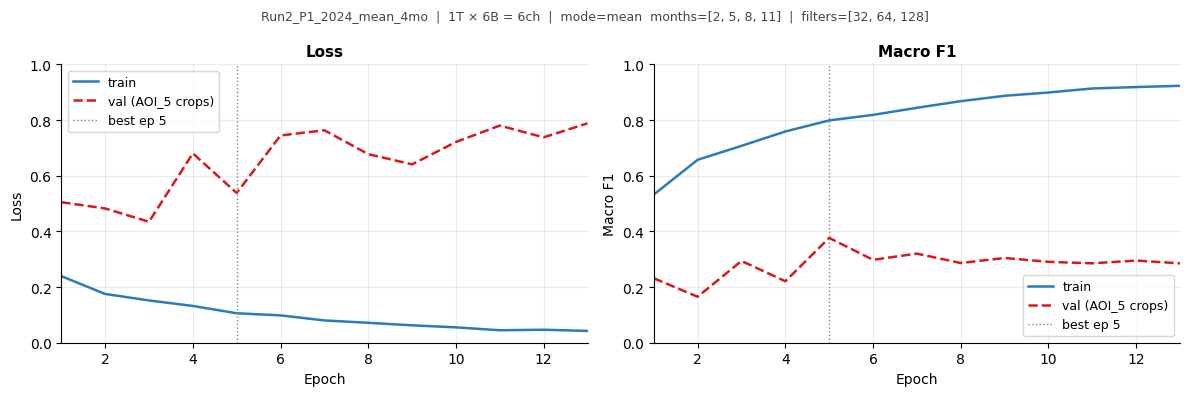

Saved → /content/exp/history_Run2_P1_2024_mean_4mo.png


In [ ]:
import matplotlib.pyplot as plt

h = history.history
def _k(base):
    for cand in [f'fus_{base}', base]:
        if cand in h: return cand
    raise KeyError(f'{base!r} not in history keys: {list(h.keys())}')
def _vk(base):
    for cand in [f'val_fus_{base}', f'val_{base}']:
        if cand in h: return cand
    return None

epochs_ran = range(1, len(h[_k('loss')]) + 1)
best_ep    = (np.argmax(h[_vk('custom_macro_f1_score')]) + 1) \
              if _vk('custom_macro_f1_score') else None

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, ylabel in [
        (axes[0], 'loss',                  'Loss'),
        (axes[1], 'custom_macro_f1_score', 'Macro F1')]:
    ax.plot(epochs_ran, h[_k(metric)], color='#2C7BB6', lw=1.8, label='train')
    if _vk(metric):
        ax.plot(epochs_ran, h[_vk(metric)], color='#D7191C', lw=1.8,
                linestyle='--', label='val (AOI_5 crops)')
    if best_ep:
        ax.axvline(best_ep, color='#888', lw=1, linestyle=':',
                   label=f'best ep {best_ep}')
    ax.set_ylim(0, 1);  ax.set_xlim(1, len(epochs_ran))
    ax.set_title(ylabel, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch');  ax.set_ylabel(ylabel)
    ax.legend(fontsize=9);  ax.grid(alpha=0.25)
    ax.spines['top'].set_visible(False);  ax.spines['right'].set_visible(False)

plt.suptitle(
    f'{RUN_LABEL}  |  {N_TIMESTEPS}T × {N_BANDS}B = {TOTAL_CHANNELS}ch'
    f'  |  mode={COMPOSITE_MODE}  months={COMPOSITE_MONTHS}'
    f'  |  filters={filters}',
    fontsize=9, color='#444')
plt.tight_layout()
_fname = RUN_LABEL.replace(' ', '_')
fig.savefig(os.path.join(EXP_DIR, f'history_{_fname}.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved →', os.path.join(EXP_DIR, f'history_{_fname}.png'))


Weights loaded from /content/exp/checkpoint_Run2_P1_2024_mean_4mo.weights.h5

Full-AOI inference — VAL set
  AOI_2: 17,865 driver px  bark=0.71  mgmt=0.35  wind=0.00  (83.9s)

VAL — per-class report (17,865 driver px):
              precision    recall  f1-score   support

 bark-beetle      0.802     0.711     0.753     14044
        mgmt      0.541     0.345     0.422      3660
  wind-throw      0.000     0.000     0.000       161

    accuracy                          0.629     17865
   macro avg      0.448     0.352     0.392     17865
weighted avg      0.741     0.629     0.679     17865

  Overall accuracy: 0.629

Full-AOI inference — TEST set
  AOI_4: 6,558 driver px  bark=0.59  mgmt=0.14  wind=0.30  (83.1s)
  AOI_5: 19,555 driver px  bark=0.68  mgmt=0.19  wind=0.60  (83.2s)

TEST — per-class report (26,113 driver px):
              precision    recall  f1-score   support

 bark-beetle      0.826     0.667     0.738     21020
        mgmt      0.230     0.151     0.182      4085


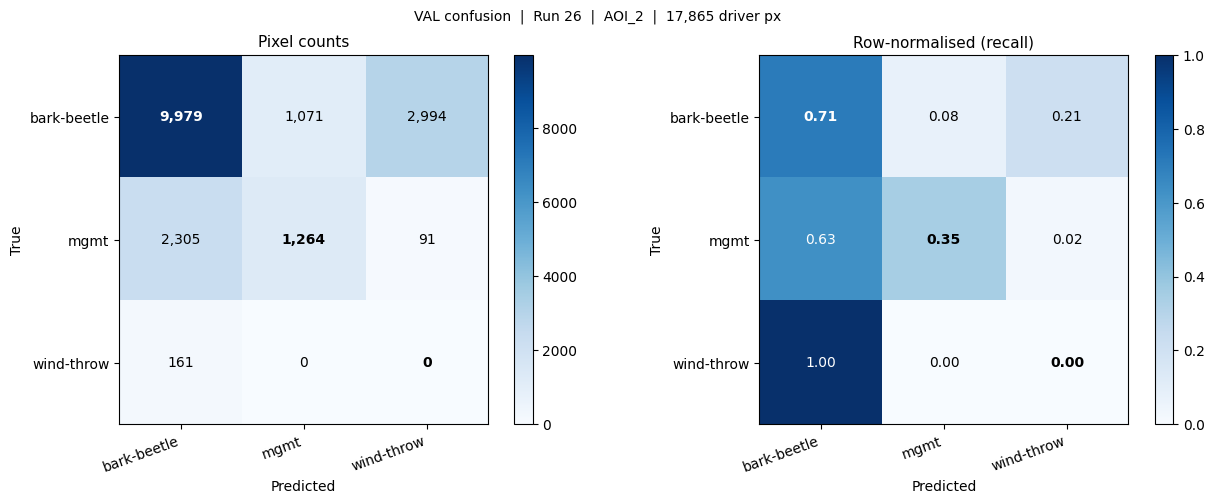

Saved → /content/exp/confusion_val_R26.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.metrics import confusion_matrix, classification_report

CLASS_NAMES = ['bark-beetle', 'mgmt', 'wind-throw']

# ── Load best checkpoint ──────────────────────────────────────────────────────
model.load_weights(ckpt_path)
print(f'Weights loaded from {ckpt_path}')

def predict_full_aoi(img_path, gt_path, tile=SIZE_CROPS):
    """Return (y_true, y_pred) flat arrays of driver pixels only (!=255)."""
    _s    = IMG_CACHE.get(img_path)
    stack = _s if _s is not None else np.load(img_path)
    _g    = GT_CACHE.get(gt_path)
    gt_orig = _g if _g is not None else np.load(gt_path)
    T, H, W, B = stack.shape
    ph = (tile - H % tile) % tile
    pw = (tile - W % tile) % tile
    stack_p = np.pad(stack, ((0,0),(0,ph),(0,pw),(0,0))) if (ph or pw) else stack
    Hp, Wp  = stack_p.shape[1], stack_p.shape[2]
    pred_map = np.zeros((Hp, Wp), dtype=np.uint8)
    for r in range(0, Hp, tile):
        for c in range(0, Wp, tile):
            crop     = stack_p[:, r:r+tile, c:c+tile, :]
            crop_img = crop.transpose(1,2,0,3).reshape(tile, tile, T*B)
            crop_img = crop_img[np.newaxis].astype(np.float32)
            logits   = model(crop_img, training=False)
            if isinstance(logits, dict): logits = next(iter(logits.values()))
            pred_map[r:r+tile, c:c+tile] = \
                np.argmax(logits[0].numpy(), axis=-1).astype(np.uint8)
    pred_map = pred_map[:H, :W]
    gt_crop  = gt_orig[:H, :W]
    mask     = gt_crop != 255
    return gt_crop[mask].astype(np.int32), pred_map[mask].astype(np.int32)

def _run_split_eval(imgs, gts, split_name):
    """Run full-AOI inference on a list of AOIs and print report."""
    # Leakage guard
    _train_keys = set(os.path.basename(p).replace('_input.npy','') for p in imgs_train)
    _eval_keys  = [os.path.basename(p).replace('_input.npy','') for p in imgs]
    _leaked     = [k for k in _eval_keys if k in _train_keys]
    if _leaked:
        raise RuntimeError(f'DATA LEAKAGE in {split_name}: {_leaked}')

    # Load into RAM cache if not already there
    for ip, gp in zip(imgs, gts):
        if ip not in IMG_CACHE:
            IMG_CACHE[ip] = np.load(ip)
        if gp not in GT_CACHE:
            GT_CACHE[gp]  = np.load(gp)

    all_true, all_pred = [], []
    print(f'\n{"="*60}')
    print(f'Full-AOI inference — {split_name.upper()} set')
    print(f'{"="*60}')
    for img_p, gt_p in zip(imgs, gts):
        aoi = os.path.basename(img_p).replace('_input.npy', '')
        t0  = time.time()
        yt, yp = predict_full_aoi(img_p, gt_p)
        all_true.extend(yt.tolist())
        all_pred.extend(yp.tolist())
        per = {c: int((yp[yt==c]==c).sum())/max(1,int((yt==c).sum())) for c in range(3)}
        print(f'  {aoi}: {len(yt):,} driver px  '
              + '  '.join(f'{CLASS_NAMES[c][:4]}={per[c]:.2f}' for c in range(3))
              + f'  ({time.time()-t0:.1f}s)')

    yt_arr = np.array(all_true)
    yp_arr = np.array(all_pred)
    cm_s      = confusion_matrix(yt_arr, yp_arr, labels=[0,1,2])
    cm_norm_s = cm_s.astype(float) / cm_s.sum(axis=1, keepdims=True).clip(min=1)
    print(f'\n{split_name.upper()} — per-class report ({len(yt_arr):,} driver px):')
    print(classification_report(yt_arr, yp_arr, labels=[0,1,2],
                                 target_names=CLASS_NAMES, digits=3, zero_division=0))
    overall = int((yt_arr==yp_arr).sum()) / len(yt_arr)
    print(f'  Overall accuracy: {overall:.3f}')
    return yt_arr, yp_arr, cm_s, cm_norm_s

# ── VAL evaluation (AOI_5) ───────────────────────────────────────────────────
y_true, y_pred, cm, cm_norm = _run_split_eval(imgs_val, gt_val, 'val')

# ── TEST evaluation (AOI_4, AOI_2) — held-out ────────────────────────────────
if imgs_test:
    y_true_test, y_pred_test, cm_test, cm_norm_test = \
        _run_split_eval(imgs_test, gt_test, 'test')
    print('\n⚠  TEST results above are the final held-out numbers.')
    print('   Do not tune hyperparameters based on these.')
else:
    print('No test AOIs defined.')

# ── Confusion matrix plot (val) ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, data, title, fmt, vmax in [
    (axes[0], cm,      'Pixel counts',            lambda v: f'{int(v):,}', None),
    (axes[1], cm_norm, 'Row-normalised (recall)',  lambda v: f'{v:.2f}',   1.0)]:
    im = ax.imshow(data, cmap='Blues', vmin=0, vmax=vmax)
    plt.colorbar(im, ax=ax)
    for i in range(3):
        for j in range(3):
            v = data[i,j]; thr = (vmax*0.5 if vmax else cm.max()*0.5)
            ax.text(j, i, fmt(v), ha='center', va='center', fontsize=10,
                    fontweight='bold' if i==j else 'normal',
                    color='white' if v>thr else 'black')
    ax.set_xticks(range(3)); ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right')
    ax.set_yticks(range(3)); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title, fontsize=11)
plt.suptitle(
    f'VAL confusion  |  Run 26  |  AOI_2  |  {len(y_true):,} driver px',
    fontsize=10)
plt.tight_layout()
fig.savefig(os.path.join(EXP_DIR, 'confusion_val_R26.png'), dpi=150)
plt.show()
print(f'Saved → {os.path.join(EXP_DIR, "confusion_val_R26.png")}')


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# §11b · Summary F1 scores — paste directly after §11 eval cell
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import f1_score
import numpy as np

CLASS_NAMES = ['bark-beetle', 'mgmt', 'wind-throw']

def _summarise(yt, yp, split_name):
    macro   = f1_score(yt, yp, average='macro',    labels=[0,1,2], zero_division=0)
    weighted= f1_score(yt, yp, average='weighted', labels=[0,1,2], zero_division=0)
    per_cls = f1_score(yt, yp, average=None,       labels=[0,1,2], zero_division=0)
    print(f'\n── {split_name} F1 SUMMARY ──────────────────────────────')
    for i, (cls, f) in enumerate(zip(CLASS_NAMES, per_cls)):
        bar = '█' * int(f * 20)
        print(f'  {cls:<14} F1={f:.3f}  {bar}')
    print(f'  {"macro avg":<14} F1={macro:.3f}  ← primary metric')
    print(f'  {"weighted avg":<14} F1={weighted:.3f}')
    return macro

val_macro  = _summarise(y_true,      y_pred,      'VAL  (AOI_2)')
test_macro = _summarise(y_true_test, y_pred_test, 'TEST (AOI_4 + AOI_5)')

print(f'\n{"="*55}')
print(f'  VAL  macro F1 : {val_macro:.3f}')
print(f'  TEST macro F1 : {test_macro:.3f}')
print(f'{"="*55}')


── VAL  (AOI_2) F1 SUMMARY ──────────────────────────────
  bark-beetle    F1=0.753  ███████████████
  mgmt           F1=0.422  ████████
  wind-throw     F1=0.000  
  macro avg      F1=0.392  ← primary metric
  weighted avg   F1=0.679

── TEST (AOI_4 + AOI_5) F1 SUMMARY ──────────────────────────────
  bark-beetle    F1=0.738  ██████████████
  mgmt           F1=0.182  ███
  wind-throw     F1=0.121  ██
  macro avg      F1=0.347  ← primary metric
  weighted avg   F1=0.627

  VAL  macro F1 : 0.392
  TEST macro F1 : 0.347


In [ ]:
# from google.colab import runtime
# runtime.unassign()
